In [ ]:
# Necessary packages to run this file:
import spectral
import spectral.io.envi as envi
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import matplotlib.image as img
from scipy.ndimage import gaussian_filter, zoom

In [14]:
path = '/n/archive/labs/hsi-data/everyday_objects/kitchen/'

folder_name1 = 'basmatiriisi'
file_number1 = '040'

folder_name2 = 'kuivahiiva'
file_number2 = '042'

folder_name3 = 'seesaminsiemen'
file_number3 = '044'

folder_name4 = "rikottu_ohrasuurimo"
file_number4 = "036"

h = envi.read_envi_header(path+folder_name1+'/capture/'+file_number1+'.hdr')['wavelength']
k = []
for i in h:
    k.append(float(i))

/tmp/ipykernel_4059385/302478163.py:53: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  denominator = white - dark
/tmp/ipykernel_4059385/302478163.py:57: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  reflectance = np.clip((raw - dark) / denominator, 0, 1)


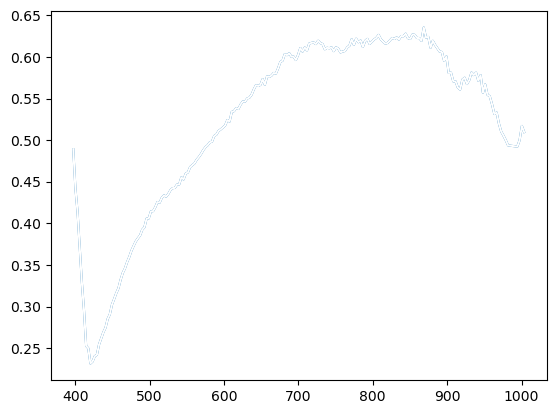

In [ ]:
# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def openImage(file_path):
    try:
        image = envi.open(file_path)
        data = image.load()

        wavelengths = image.metadata.get('wavelength', None)
        if wavelengths:
            wavelengths = [float(w) for w in wavelengths]

        return data, wavelengths

    except Exception as e:
        print(f"  Error loading {path + folder_name + '/capture/' + file_number + '.hdr'}: {e}")
        return None, None


# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def load_and_compute_reflectance(path, folder_name, file_number):
    folder_path = path + folder_name + '/capture/'
    paths = {
        'raw':   os.path.join(folder_path, f"{file_number}.hdr"),
        'white': os.path.join(folder_path, f"WHITEREF_{file_number}.hdr"),
        'dark':  os.path.join(folder_path, f"DARKREF_{file_number}.hdr"),
    }

    for key, p in paths.items():
        if not os.path.isfile(p):
            print(f"  Missing {key} file: {p}")
            return None, None

    raw, wavelengths = openImage(paths['raw'])
    white, _ = openImage(paths['white'])
    dark, _  = openImage(paths['dark'])

    if any(x is None for x in [raw, white, dark]):
        print("  Failed to load one or more image cubes.")
        return None, None
    '''
    # Resize references to match the raw image spatial dimensions
    _, raw_cols, _ = raw.shape
    _, ref_cols, _ = white.shape
    factor = (1.0, raw_cols / ref_cols, 1.0)
    white = zoom(white, factor, order=1)
    dark  = zoom(dark,  factor, order=1)

    if raw.shape != white.shape or raw.shape != dark.shape:
        raise ValueError(
            f"Dimension mismatch after resizing: raw {raw.shape}, "
            f"white {white.shape}, dark {dark.shape}"
        )
    '''
    denominator = white - dark
    denominator[denominator == 0] = 1e-6

    # np.clip: limits the values between given given values, here 0 and 1
    reflectance = np.clip((raw - dark) / denominator, 0, 1)
    return reflectance, wavelengths

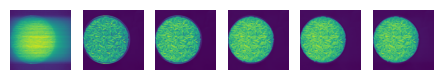

In [21]:
data_raw = spectral.envi.open('/n/archive/labs/hsi-data/everyday_objects/kitchen/basmatiriisi/capture/040.hdr')

cube_raw = np.array(data_raw.asarray())

i = 6

for p in range(0, i):
    plt.subplot(1, i+1, p+1)
    plt.imshow(cube_raw[:,:,int(p*(204/i))])
    plt.axis('off')

plt.show()